# <center>Sci‑Fi Movie Recommendation System for "Cold-Start" Users: Collaborative Filtering vs. Matrix Factorization </center>

# Part 2: KNN Modeling 


This notebook builds on the data prepared in `01_data_prep.ipynb` (Sci-Fi ratings, active/cold-start data split). It addresses Business Question 1 (cold-start reliability) through KNN modeling and a genre-granularity case study. See `01_data_prep.ipynb` or the **README** for full business context.

### Setting Environment & Data Loading

In [1]:
# Required libraries
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity

from IPython.display import Markdown, display
from wordcloud import WordCloud
%matplotlib inline


In [2]:
# Read data files
df_active = pd.read_parquet('ml-32m/df_active.parquet')
df_cold_start = pd.read_parquet('ml-32m/df_cold_start.parquet')
print("Successfully read the files!")

Successfully read the files!


In [3]:
print(f"Active users: {df_active['userId'].nunique()}")
print(f"Active ratings: {len(df_active)}")

print(f"Cold-start users: {df_cold_start['userId'].nunique()}")
print(f"Cold-start ratings: {len(df_cold_start)}")

print(f"Total users: {df_active['userId'].nunique() + df_cold_start['userId'].nunique()}")
print(f"Total ratings: {len(df_active) + len(df_cold_start)}")

Active users: 14009
Active ratings: 560517
Cold-start users: 5991
Cold-start ratings: 22153
Total users: 20000
Total ratings: 582670


## Feature Engineering
### User-Movie Profile Matrix & Per-User Mean Imputation
To find each user's pattern of ratings across movies, we restructure the data into a user-movie matrix: each row represents a user, each column represents a movie, and each cell holds that user's rating (or an imputed value, for memory-based KNN). This wide-format representation will let us compute similarity between users or extract latent factors, neither of which would be possible from the raw long-format ratings table.

In [4]:
user_movie_matrix = df_active.pivot(index = 'userId', columns = 'movieId', values = 'rating')
print(user_movie_matrix.shape)

(14009, 2997)


### Pre-Imputation Sparsity Check

In [5]:
target_movie = df_active['movieId'].value_counts().index[0]
valid_users = user_movie_matrix[target_movie].dropna().index

# Number of observed ratings per user before imputation
observed_per_user = user_movie_matrix.notna().sum(axis=1)

# Total number of movies
total_movies = user_movie_matrix.shape[1]

# Sparsity metric: Percentage originally observed
observed_percentage = observed_per_user / total_movies * 100

# For heatmap, the highest rated 30 movies and the users
before_sample = user_movie_matrix.iloc[:30, :30].copy()
print(">> Completed!")

>> Completed!


In [6]:
user_movie_matrix.shape

(14009, 2997)

**Rating Bias & User-Mean Centering**   
Some users are naturally harsh critics (e.g., rarely give 5s), others are lenient (e.g., rarely give below 4), and treating a "4" the same way for both users can distort both the model and the evaluation metrics. As a standard fix, user-mean centering was applied. First, we drop target movie to prevent data leakage because imputing

In [7]:
# Drop target_movie before computing means (to prevent data leakage)
feature_matrix_raw = user_movie_matrix.drop(columns=[target_movie])

# Mean-center the raw ratings
feature_means = feature_matrix_raw.mean(axis=1)
feature_matrix_centered = feature_matrix_raw.sub(feature_means, axis=0)

### Imputing missing values  
Fill missing ratings with user's mean rating (0) of user-centered means.  

In [8]:
feature_matrix_imputed = feature_matrix_centered.fillna(0)

total_nans = feature_matrix_imputed.isna().sum().sum()
print(f"Total missing values remaining: {total_nans}")

Total missing values remaining: 0


### Imputation Diagnostics

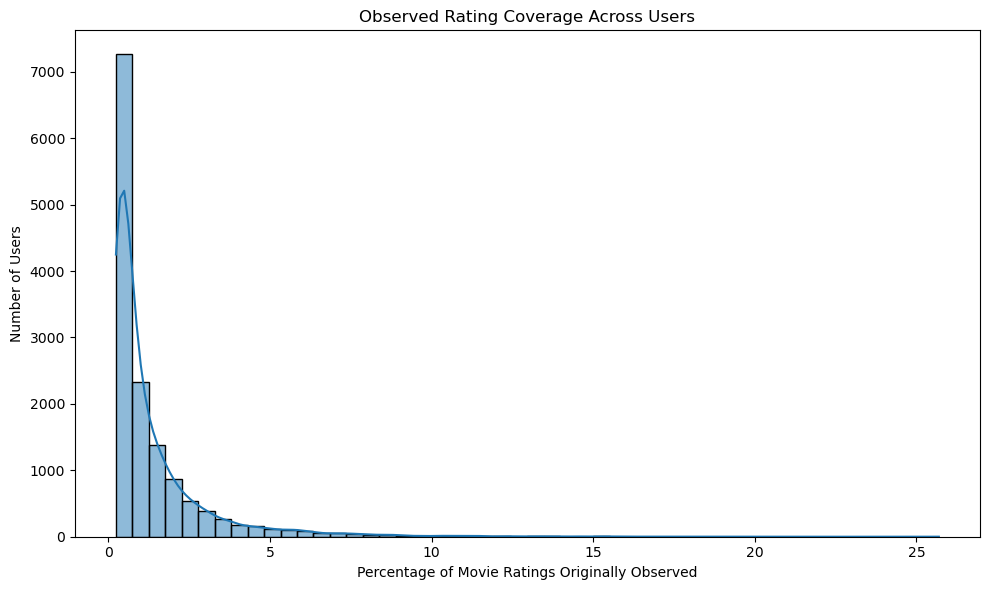

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(
    observed_percentage,
    bins=50,
    kde=True
)

plt.xlabel("Percentage of Movie Ratings Originally Observed")
plt.ylabel("Number of Users")
plt.title("Observed Rating Coverage Across Users")

plt.tight_layout()
plt.show()

**Key Insights**  

The overwhelming majority of users have directly rated only a small fraction of movies, most fall under 5% observed coverage, meaning the vast majority of each user's row in the matrix is imputed rather than observed. 

###  Before-After Centering&Imputation Plots

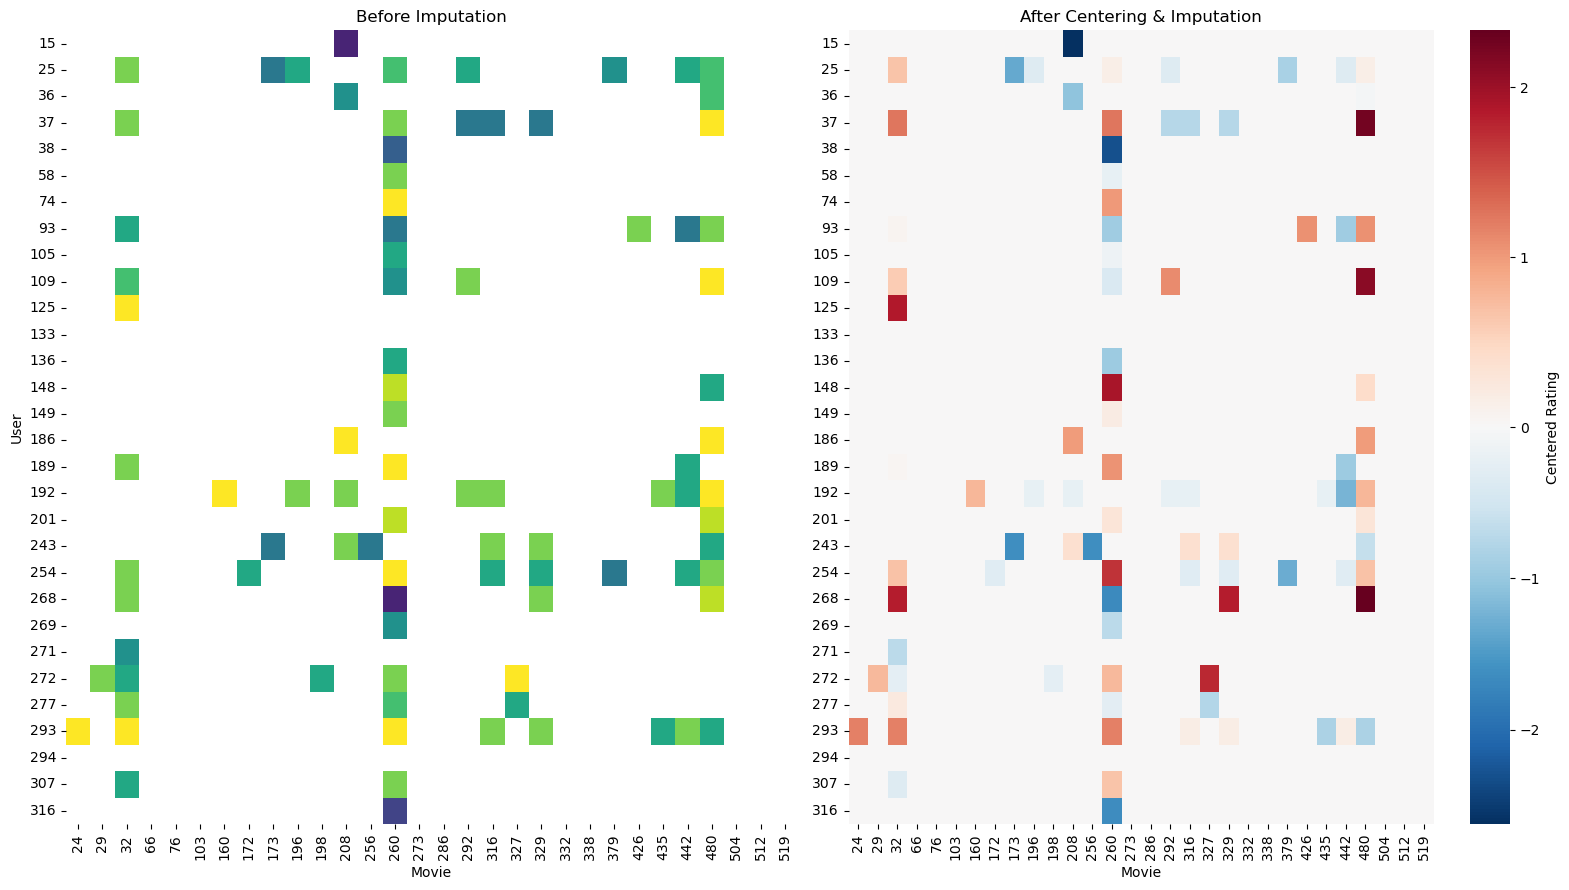

In [10]:
from matplotlib.colors import TwoSlopeNorm

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# BEFORE — raw scale, unchanged
sns.heatmap(before_sample.iloc[:30, :30], cmap="viridis", vmin=0, vmax=5, ax=axes[0], cbar=False)
axes[0].set_title("Before Imputation")
axes[0].set_xlabel("Movie")
axes[0].set_ylabel("User")

# AFTER — centered scale, diverging colormap around 0
after_data = feature_matrix_imputed.iloc[:30, :30]
norm = TwoSlopeNorm(vmin=after_data.min().min(), vcenter=0, vmax=after_data.max().max())
sns.heatmap(after_data, cmap="RdBu_r", norm=norm, ax=axes[1], cbar=True, cbar_kws={"label": "Centered Rating"})
axes[1].set_title("After Centering & Imputation")
axes[1].set_xlabel("Movie")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Key Insights**  

- The plot shows the 30 most-rated movies in the filtered dataset, for visual clarity.
- The "Before" panel shows how sparse real user-movie data actually is, most cells are empty even among the platform's most popular movies, since no single user rates more than a small fraction of the catalog. The "After" panel shows the consequence of per-user mean imputation: nearly every gap is filled with a value close to that user's personal average, producing dense, artificially smooth rows.
- This contrast highlights the core tradeoff behind memory-based collaborative filtering: imputation is necessary for KNN to compute similarity across a shared feature space, but it also manufactures information that was never observed. Low-activity users are affected most severely, a user with only one or two real ratings ends up with a row that's almost entirely their own repeated average, which can distort similarity calculations built on top of it.
- In summary, these plots confirm that mean imputation isn't a minor correction for a few sparse users, it's the dominant characteristic of the dataset, reinforcing why model-based approaches like SVD/NMF, which train only on observed ratings, offer a meaningful alternative to memory-based methods reliant on a heavily imputed matrix. This is a key reason the project also evaluates SVD/NMF, which learn from observed ratings only, rather than committing to a fully imputed matrix.

### Specifying Features and Target Movie

In [11]:
# Center y using the feature-only mean — avoids leakage
target_raw = user_movie_matrix.loc[valid_users, target_movie]
y = target_raw - feature_means.loc[valid_users]

x = feature_matrix_imputed.loc[valid_users, :]

In [12]:
print(f"Users with complete data: {len(y)}" )

Users with complete data: 8724


## Modeling: KNN (Baseline)

### Train and Test Split

In [13]:
# 80% training set and 20% testing set 
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.80, random_state=72)
print(type(x_train), type(y_train))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


### Hyperparameter Tuning  
Create a list of evenly integer k values to test as hyperparameters

In [14]:
# Choosing k range from 1 to 50
k_value_min = 1
k_value_max = 50

k_list = np.linspace(k_value_min, k_value_max, num=50, dtype=int)
print(">> Completed!")

>> Completed!


### Model fit
Instead of K-Nearest Neighbors' default Euclidian distance, first, Cosine similarity was used to measure similarity between users. However, model comparison with other metrics showed that Manhattan similarity metric provided the best RMSE and MAE results. Also, in order to take the rating of close neighboring values into account, Inverse Distance Weigting (i.e., 'distance') was chosen instead of the default uniform weighting.

In [15]:
max_k = min(k_value_max, x_train.shape[0])

nn = NearestNeighbors(n_neighbors=max_k, metric='manhattan', n_jobs=-1)
nn.fit(x_train)

print(f"Computing distances for {x_train.shape[0]} train users, {x_test.shape[0]} test users...")
distances, indices = nn.kneighbors(x_test)
print("Distance computation complete.")

y_train_array = y_train.values

knn_dict = {}
for k_value in k_list:
    k = int(k_value)
    if k > max_k:
        break
    k_distances = distances[:, :k]
    k_indices = indices[:, :k]
    # Manually calculating weighted kNN prediction
    weights = 1 / np.where(k_distances == 0, 1e-10, k_distances) # inverse distance weights
    weighted_sum = np.sum(weights * y_train_array[k_indices], axis=1)
    weight_total = np.sum(weights, axis=1)
    y_pred = weighted_sum / weight_total 
    MSE = mean_squared_error(y_test, y_pred)
    knn_dict[k] = MSE

Computing distances for 6979 train users, 1745 test users...
Distance computation complete.


### The source of weighted k-NN formulas

The baseline k-nearest-neighbor prediction rule for a quantitative output averages the responses 
of the k nearest training points equally as defined in
**Hastie, Tibshirani & Friedman (2017), Equation (2.8), page 14** as:

$$
\hat{Y}(x) = \frac{1}{k} \sum_{x_i \in N_k(x)} y_i
$$


This project instead uses the standard inverse-distance-weighted extension of this rule, in which each neighbor's contribution is scaled by the inverse of its distance to the query point, so that closer neighbors have proportionally greater influence on the prediction:

$$
\hat{Y}(x) = \frac{\sum_{i=1}^{k} w_i \, y_i}{\sum_{i=1}^{k} w_i}, w_i = \frac{1}{d(x, x_i)}
$$

This weighting scheme follows scikit-learn's `KNeighborsRegressor` 'distance' option (scikit-learn documentation, `sklearn.neighbors.KNeighborsRegressor`).

### Visualization for optimal k

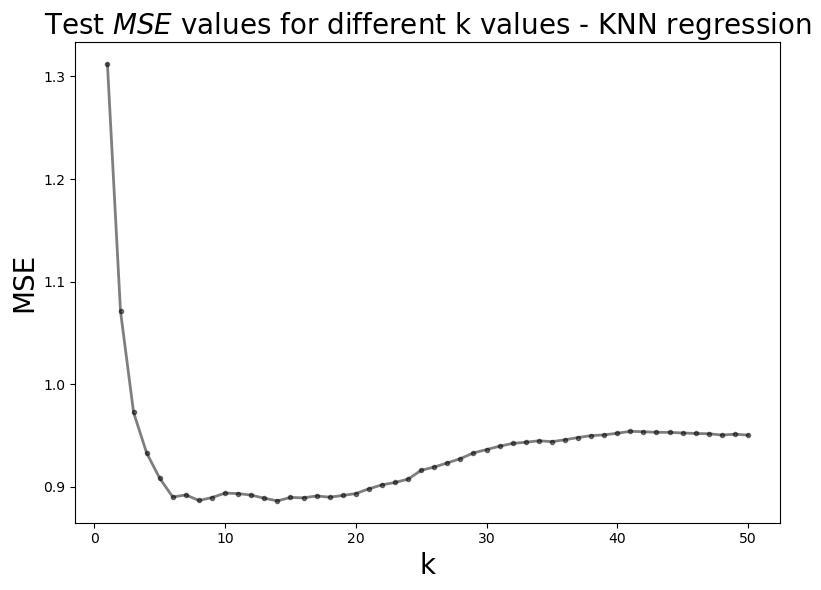

In [16]:
# Plot the relation between the k values and MSE
plt.figure(figsize=(8,6))
plt.plot(list(knn_dict.keys()), list(knn_dict.values()),'k.-',alpha=0.5,linewidth=2)
plt.xlabel('k',fontsize=20)
plt.ylabel('MSE',fontsize = 20)
plt.title('Test $MSE$ values for different k values - KNN regression',fontsize=20)
plt.tight_layout()


## Model Selection and Evaluation

In [17]:
min_mse = min(knn_dict.values())
tolerance = 0.01  # Adjust for bias-variance tradeoff

# Find smallest k with minimum MSE within the tolerance range
best_k_smallest = min([k for k, mse in knn_dict.items() if abs(mse - min_mse) <= tolerance])


print(f"Best k by tolerance: {best_k_smallest}, MSE = {knn_dict[best_k_smallest]:.4f}")
print(f"Global minimum MSE: {min_mse:.4f} (at k = {min(knn_dict, key=knn_dict.get)})")
print(f"Difference: {knn_dict[best_k_smallest] - min_mse:.4f} (tolerance: {tolerance})")

Best k by tolerance: 6, MSE = 0.8900
Global minimum MSE: 0.8863 (at k = 14)
Difference: 0.0038 (tolerance: 0.01)


In [18]:
candidate_ks = [10, 14, 15, 20, 25, 30, 35,  40, 50]

print("k | MSE")
print("-" * 20)
for k in candidate_ks:
    if k in knn_dict:
        print(f"{k:2d} | {knn_dict[k]:.4f}")
    else:
        print(f"{k:2d} | not in knn_dict (check k_list spacing)")

k | MSE
--------------------
10 | 0.8939
14 | 0.8863
15 | 0.8896
20 | 0.8934
25 | 0.9161
30 | 0.9363
35 | 0.9440
40 | 0.9522
50 | 0.9504


**Key Insight**  
Centering ratings to correct for individual rater bias increased MSE relative to the uncentered baseline (approximately 0.73 → 0.89 at comparable k). This reflects the removal of a level-matching shortcut present in the uncentered pipeline, where imputed cells (dominated by each user's own mean) allowed the model to implicitly predict toward a user's typical rating level rather than genuine shared taste. Once centered, imputed cells carry no discriminative signal, and prediction relies solely on the sparse set of genuinely observed, shared ratings, a harder but more methodologically honest task. Notably, the relationship between k and MSE also reverses under centering: smaller neighborhoods (k=14) now outperform larger ones, since additional neighbors increasingly dilute the limited genuine signal available.

In [19]:
best_k_smallest = 14
# Compute the R2_score
model = KNeighborsRegressor(n_neighbors=best_k_smallest, metric='manhattan', weights='distance',n_jobs=-1)
model.fit(x_train, y_train)
y_pred_test = model.predict(x_test)
print(f"The R2 score is {r2_score(y_test, y_pred_test):.4f}")

The R2 score is -0.1407


### Methodological Insight:  
Under centered ratings, the model achieves an $R^2$ of -0.14, performing worse than a naive baseline of predicting each user's own average (0 on the centered scale). This result, together with the MSE pattern above, indicates that the uncentered model's earlier apparent performance was driven substantially by implicit rating-level matching rather than genuine shared-taste signal. With that shortcut removed, KNN similarity computed over the full, heavily-imputed feature vector struggles to isolate meaningful signal from the sparse ~5% of genuinely observed ratings. This motivates the comparison against SVD/NMF, which learn directly from observed ratings only, avoiding this imputation-driven dilution entirely.

In [20]:
# Root mean squared error (RMSE) and Mean absolute error (MAE)
best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
best_mae = mean_absolute_error(y_test, y_pred_test)

print(best_rmse)
print(best_mae)

0.9312784186434869
0.7591146577976217


In [21]:

display(Markdown(f"""
**Key Insights**

The optimal KNN model (k={best_k_smallest}, Manhattan distance) achieves an RMSE of {best_rmse:.2f} and MAE of {best_mae:.2f}, meaning predictions are typically off by well under one rating point.\n The R² of {r2_score(y_test, y_pred_test):.2f} confirms only modest explanatory power, expected given the sparsity and imputation involved, reinforcing the value of comparing against SVD/NMF later in this project.
"""))


**Key Insights**

The optimal KNN model (k=14, Manhattan distance) achieves an RMSE of 0.93 and MAE of 0.76, meaning predictions are typically off by well under one rating point.
 The R² of -0.14 confirms only modest explanatory power, expected given the sparsity and imputation involved, reinforcing the value of comparing against SVD/NMF later in this project.


In [22]:
# Full analysis based on the best model
best_k = best_k_smallest
final_model = KNeighborsRegressor(
    n_neighbors=best_k, 
    metric='manhattan', 
    weights='distance'
)
final_model.fit(x, y)

print(f"Final model trained on {len(y)} users with k={best_k}")

Final model trained on 8724 users with k=14


### Performance metrics
R-squared was not reported here because recommender systems are commonly evaluated using RMSE and MAE due to sparse and bounded rating distributions.

In [23]:
print(f"RMSE: {best_rmse:.3f}")
print(f"MAE: {best_mae:.3f}")

RMSE: 0.931
MAE: 0.759


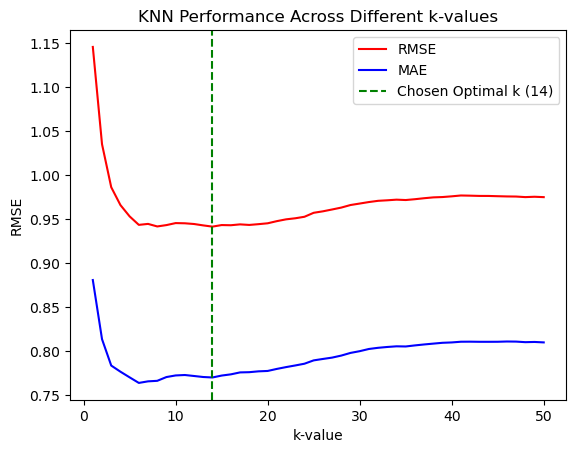

In [24]:
k_values = range(1, 51)
rmse_scores, mae_scores = [], []

y_train_array = y_train.values  # skip if already defined earlier

for k in k_values:
    k_distances = distances[:, :k]
    k_indices = indices[:, :k]
    weights = 1 / np.where(k_distances == 0, 1e-10, k_distances)
    weighted_sum = np.sum(weights * y_train_array[k_indices], axis=1)
    weight_total = np.sum(weights, axis=1)
    preds = weighted_sum / weight_total

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    rmse_scores.append(rmse)
    mae_scores.append(mae)

plt.plot(k_values, rmse_scores, color='red', label='RMSE')
plt.plot(k_values, mae_scores, color='blue', label='MAE')
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Chosen Optimal k ({best_k})')
plt.xlabel("k-value")
plt.ylabel("RMSE")
plt.title("KNN Performance Across Different k-values")
plt.legend(loc='upper right')
plt.show()

In [25]:
# Model Comparison for different distance metrics: 
metrics_to_test = ['euclidean', 'cosine', 'manhattan']

# Create empty storage lists
real_rmse = []
real_mae = []

for metric in metrics_to_test:
    # Configure the model with  best k and the current metric
    model = KNeighborsRegressor(n_neighbors=best_k, metric=metric, weights='distance')
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    real_rmse.append(rmse)
    real_mae.append(mae)

# Construct the final results
results = pd.DataFrame({
    'Metric': ['Euclidean', 'Cosine', 'Manhattan'],
    'RMSE': real_rmse,
    'MAE': real_mae
})
# The results
print(results)

      Metric      RMSE       MAE
0  Euclidean  0.910020  0.731097
1     Cosine  0.828075  0.631557
2  Manhattan  0.931278  0.759115


**Key Insights:**  
Manhattan distance provides the lowest RMSE and MAE.

### Precision & Recall  
Since this notebook's KNN pipeline predicts ratings for a single fixed target movie per user (rather than ranking multiple candidate movies), precision and recall are reported here as binary classification metrics for that target movie, using a relevance threshold of 0 on the centered scale (i.e., a rating above the user's own average), rather than a fixed absolute threshold or the ranked precision@k/recall@k formulation. The multi-item ranking-based precision@k/recall@k, better suited to evaluating recommendation quality across a candidate set, is computed in the SVD/NMF notebook, where the model architecture naturally supports predicting ratings across many items per user.

**Precision** measures how often the model is correct when it predicts a user will rate the target movie as relevant (predicted centered rating > 0, i.e., above their own average): of all users flagged as "will like this movie more than usual," what fraction actually did?

$$\text{Precision} = \frac{T_p}{T_p + F_p}$$

**Recall** measures how many of the truly relevant users (those who actually rated the movie above their own average) the model successfully identified: of all users who genuinely liked the movie relative to their own norm, what fraction did the model catch?

$$\text{Recall} = \frac{T_p}{T_p + F_n}$$

where $T_p$ (true positives) are users correctly predicted as relevant, $F_p$ (false positives) are users incorrectly predicted as relevant, and $F_n$ (false negatives) are relevant users the model failed to flag.

In [26]:
threshold = 0.0  # centered scale: 0 = user's own average; positive = above their own norm

y_pred_relevant = y_pred_test >= threshold
y_true_relevant = y_test >= threshold

true_positives = (y_pred_relevant & y_true_relevant).sum()
predicted_positives = y_pred_relevant.sum()
actual_positives = y_true_relevant.sum()

precision = true_positives / predicted_positives if predicted_positives > 0 else 0
recall = true_positives / actual_positives if actual_positives > 0 else 0

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")

Precision: 0.812
Recall: 0.687


In [27]:
display(Markdown(f"""  
**Key Insights**  
Precision = {precision:.3f}: Of all the times the model predicted a user would rate the target movie above their own average ("relevant"), it was correct {precision*100:.1f}% of the time. When the model says "this user will like this movie more than usual," it's right the large majority of the time, few false alarms.

Recall = {recall:.3f}: Of all the users who actually rated the movie above their own average, the model correctly flagged only {recall*100:.1f}% of them. It's missing a meaningful share of the users who genuinely liked the movie relative to their own norm, false negatives, real relevant users the model failed to identify as such.
"""))

  
**Key Insights**  
Precision = 0.812: Of all the times the model predicted a user would rate the target movie above their own average ("relevant"), it was correct 81.2% of the time. When the model says "this user will like this movie more than usual," it's right the large majority of the time, few false alarms.

Recall = 0.687: Of all the users who actually rated the movie above their own average, the model correctly flagged only 68.7% of them. It's missing a meaningful share of the users who genuinely liked the movie relative to their own norm, false negatives, real relevant users the model failed to identify as such.


## Case Study: Genre Granularity and Similarity Quality
We need to find top 5 nearest neighbors (5 most similar users) to the target user via KNN on the full Sci-Fi matrix

In [28]:
k = 6 # including the target user
user_0 = x.iloc[0].values.reshape(1, -1)
case_distances, case_indices = final_model.kneighbors(user_0, n_neighbors=k)  

similar_user_ids = x.index[case_indices[0]].tolist()

# Remove the query user themselves from their own neighbor list
query_user_id = x.index[0]
similar_user_ids = [uid for uid in similar_user_ids if uid != query_user_id][:5]

print(f"\nThe 5 most similar users to the User {query_user_id}:")
print(similar_user_ids)


The 5 most similar users to the User 25:
[115316, 17825, 55138, 49640, 2312]


In [29]:
display(Markdown(f"""  
**Insight:**  
For User {query_user_id}, the model surfaces five other users whose overall rating 
patterns most closely match theirs, in this example, users {similar_user_ids} demonstrating how KNN translates raw rating similarity into concrete, explainable peer groups."""))

  
**Insight:**  
For User 25, the model surfaces five other users whose overall rating 
patterns most closely match theirs, in this example, users [115316, 17825, 55138, 49640, 2312] demonstrating how KNN translates raw rating similarity into concrete, explainable peer groups.

Comparison users: [np.int32(25), 115316, 17825, 55138, 49640, 2312]


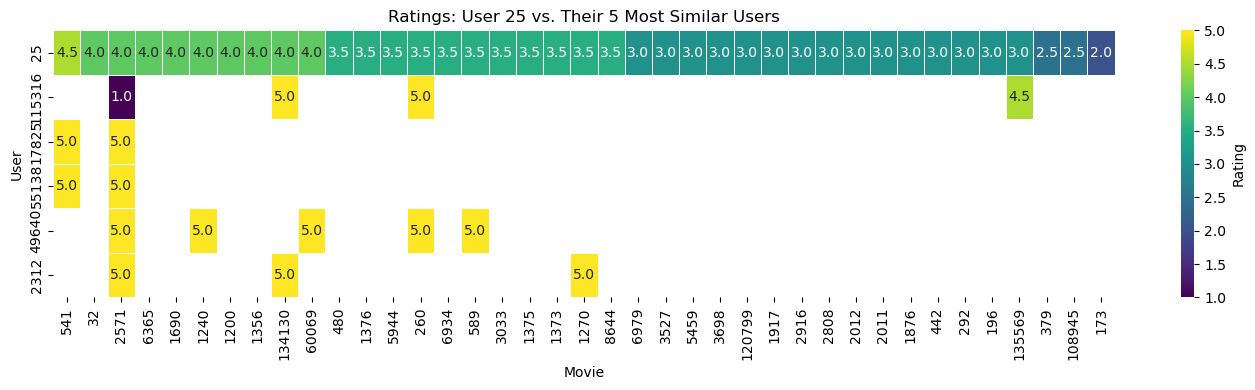

In [30]:
comparison_users = [query_user_id] + similar_user_ids
print("Comparison users:", comparison_users) 

original_ratings = df_active.pivot(
    index='userId', columns='movieId', values='rating'
)   

query_rated = original_ratings.loc[query_user_id].dropna()

N = 100
top_movies = query_rated.sort_values(ascending=False).head(N).index

comparison_matrix = original_ratings.loc[comparison_users, top_movies]

plt.figure(figsize=(14, 4))
sns.heatmap(
    comparison_matrix,
    annot=True,
    fmt='.1f',
    cmap='viridis',
    cbar_kws={'label': 'Rating'},
    linewidths=0.5,
)
plt.title(f"Ratings: User {query_user_id} vs. Their 5 Most Similar Users")
plt.xlabel("Movie")
plt.ylabel("User")
plt.tight_layout()
plt.show()

In [31]:
# Keep IDs and distances together, then filter out the self-match from both
paired = list(zip(x.index[case_indices[0]].tolist(), case_distances[0].tolist()))
paired = [(uid, dist) for uid, dist in paired if uid != query_user_id][:5]

similar_user_ids = [uid for uid, dist in paired]
similar_distances = [dist for uid, dist in paired]

print(f"\nThe 5 most similar users to User {query_user_id}:")
for uid, dist in paired:
    print(f"  User {uid}: distance = {dist:.3f}")


The 5 most similar users to User 25:
  User 115316: distance = 16.257
  User 17825: distance = 16.316
  User 55138: distance = 16.316
  User 49640: distance = 16.316
  User 2312: distance = 16.316


**Key Insights**  
- Visualization of similar users' actual (non-imputed) ratings on shared movies reveal that agreement is weaker than expected.
- It is possible that lumping all Sci-Fi sub-genres together may be diluting genuine similarity
- Checking genres, using EFA on genre co-occurrence to identify a coherent latent factor (Action/Adventure or Animation/Children), recomputing neighbors within just that subgroup may improve similarity. 

### An Exploratory Approach: Using Exploratory Factor Analysis
Exploratory factor analysis, a technique originating in psychometrics, can be used to uncover latent genre structure within the Sci-Fi catalog.

In [32]:
df_active['genres'].unique()

array(['Action|Adventure|Sci-Fi', 'Action|Adventure|Sci-Fi|Thriller',
       'Adventure|Comedy|Sci-Fi', 'Action|Adventure|Comedy|Sci-Fi',
       'Action|Adventure|Sci-Fi|IMAX',
       'Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX',
       'Drama|Romance|Sci-Fi', 'Mystery|Sci-Fi|Thriller',
       'Action|Crime|Sci-Fi', 'Horror|Sci-Fi',
       'Action|Drama|Sci-Fi|Thriller', 'Action|Sci-Fi|Thriller',
       'Action|Sci-Fi', 'Action|Adventure|Horror|Sci-Fi',
       'Action|Horror|Sci-Fi', 'Drama|Sci-Fi|Thriller',
       'Action|Romance|Sci-Fi|Thriller',
       'Adventure|Comedy|Sci-Fi|Western', 'Comedy|Sci-Fi',
       'Action|Comedy|Sci-Fi', 'Action|Adventure|Sci-Fi|Thriller|IMAX',
       'Adventure|Animation|Children|Romance|Sci-Fi',
       'Action|Crime|Sci-Fi|IMAX', 'Adventure|Drama|Sci-Fi',
       'Crime|Drama|Sci-Fi|Thriller', 'Mystery|Romance|Sci-Fi|Thriller',
       'Action|Crime|Mystery|Sci-Fi|Thriller',
       'Action|Sci-Fi|Thriller|IMAX',
       'Action|Drama|Mystery|Sci-Fi|

In [33]:
# One-hot encode genres (dropping Sci-Fi)
scifi_unique_movies = df_active.drop_duplicates(subset='movieId')
genre_dummies = scifi_unique_movies['genres'].str.get_dummies(sep='|').drop(columns=['Sci-Fi'], errors='ignore')

# Check whether EFA is appropriate for this data
chi_square, p_value = calculate_bartlett_sphericity(genre_dummies)
kmo_all, kmo_model = calculate_kmo(genre_dummies)
print(f"Bartlett's test p-value: {p_value:.4f}")  # ideally < 0.05
print(f"KMO score: {kmo_model:.3f}")  # needs to be > 0.6, ideally > 0.7

# If both check out, EFA
fa = FactorAnalyzer(n_factors=4, rotation='varimax')
fa.fit(genre_dummies)
loadings = pd.DataFrame(fa.loadings_, index=genre_dummies.columns)
print(loadings.round(2))

Bartlett's test p-value: 0.0000
KMO score: 0.585
                0     1     2     3
Action      -0.08  0.71 -0.22 -0.02
Adventure    0.33  0.40 -0.07  0.02
Animation    0.35  0.10 -0.00 -0.03
Children     0.57 -0.03 -0.09  0.04
Comedy       0.32 -0.14  0.05 -0.21
Crime       -0.06  0.05  0.02  0.16
Documentary -0.00 -0.04  0.03 -0.06
Drama       -0.09 -0.05  0.51  0.22
Fantasy      0.30  0.09  0.06  0.07
Film-Noir    0.03  0.01  0.03  0.06
Horror      -0.30 -0.34 -0.33 -0.01
IMAX        -0.00  0.21 -0.04  0.01
Musical      0.10 -0.05  0.04 -0.05
Mystery     -0.04 -0.09  0.04  0.41
Romance      0.05 -0.06  0.30 -0.05
Thriller    -0.32  0.02 -0.11  0.33
War          0.00  0.07  0.04  0.01
Western     -0.03  0.03 -0.03 -0.05


/opt/anaconda3/lib/python3.13/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


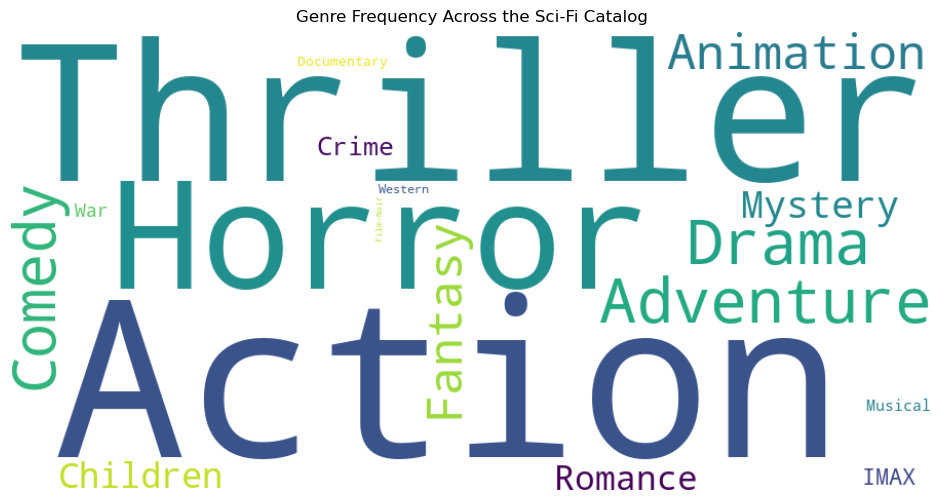

In [34]:
# Reuse your genre_dummies (already built earlier for EFA)
genre_counts = genre_dummies.sum().to_dict()

wc = WordCloud(width=900, height=450, background_color='white', colormap='viridis')
wc.generate_from_frequencies(genre_counts)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Genre Frequency Across the Sci-Fi Catalog')
plt.show()

**Key Insights**  
EFA results show that the co-occurrance of Action and Adventure genres is a plausible candidate to be a latent factor for viewing preference. Standardized factor loadings are 0.71 for Action genre and 0.40 for Adventure genre.

**Limitation**  
The KMO measure of sampling adequacy was 0.585, falling just below the conventional 0.6 threshold for 'mediocre' sampling adequacy, while Bartlett's test of sphericity was highly significant (p < 0.001), confirming sufficient inter-item correlation. Nevertheless, these results suggest EFA here should be interpreted as an exploratory.
Although the binary genre variables technically violate EFA's continuous data assumption, the resulting factor groupings still produced a meaningful improvement in prediction accuracy (in the next case study). This suggests that the underlying genre clusters are likely real even if the statistical method wasn't a perfect fit. Therefore, the practical value justified the approach and is reported here.

In [35]:
# Identify movies that specify both the Action/Adventure genres
factor1_genres = ['Action', 'Adventure']

genre_dummies = df_active['genres'].str.get_dummies(sep='|')
factor1_mask = genre_dummies[factor1_genres].sum(axis=1) > 0  # movie has Action OR Adventure

factor1_movies = df_active.loc[factor1_mask, 'movieId']
print(f"Movies in Action/Adventure factor: {len(factor1_movies)}")

# Restrict ratings to this subgroup
factor1_ratings = df_active[df_active['movieId'].isin(factor1_movies)]
print(f"Ratings: {len(factor1_ratings)}, Users: {factor1_ratings['userId'].nunique()}")

# Rebuild the user-movie matrix for just this subgroup
factor1_matrix = factor1_ratings.pivot(index='userId', columns='movieId', values='rating')

# Re-run the same query user's similarity search, but now within this subgroup only
if query_user_id in factor1_matrix.index:
    # Center ratings within this subgroup, same approach as the main pipeline
    factor1_feature_matrix_raw = factor1_matrix.drop(columns=[c for c in [target_movie] if c in factor1_matrix.columns], errors='ignore')
    factor1_feature_means = factor1_feature_matrix_raw.mean(axis=1)
    factor1_feature_matrix_centered = factor1_feature_matrix_raw.sub(factor1_feature_means, axis=0)
    x_f1 = factor1_feature_matrix_centered.fillna(0)

    user_0_f1 = x_f1.loc[[query_user_id]].values.reshape(1, -1)
    nn_f1 = NearestNeighbors(n_neighbors=6, metric='manhattan')
    nn_f1.fit(x_f1)
    distances_f1, indices_f1 = nn_f1.kneighbors(user_0_f1)

    similar_ids_f1 = x_f1.index[indices_f1[0]].tolist()
    similar_ids_f1 = [uid for uid in similar_ids_f1 if uid != query_user_id][:5]
    print(f"Similar users within Action/Adventure subgroup: {similar_ids_f1}")
else:
    print(f"User {query_user_id} has no ratings in the Action/Adventure subgroup.")

Movies in Action/Adventure factor: 412914
Ratings: 412914, Users: 14008
Similar users within Action/Adventure subgroup: [174730, 58889, 2155, 1470, 32636]


Comparison users (Action/Adventure subgroup): [np.int32(25), 174730, 58889, 2155, 1470, 32636]


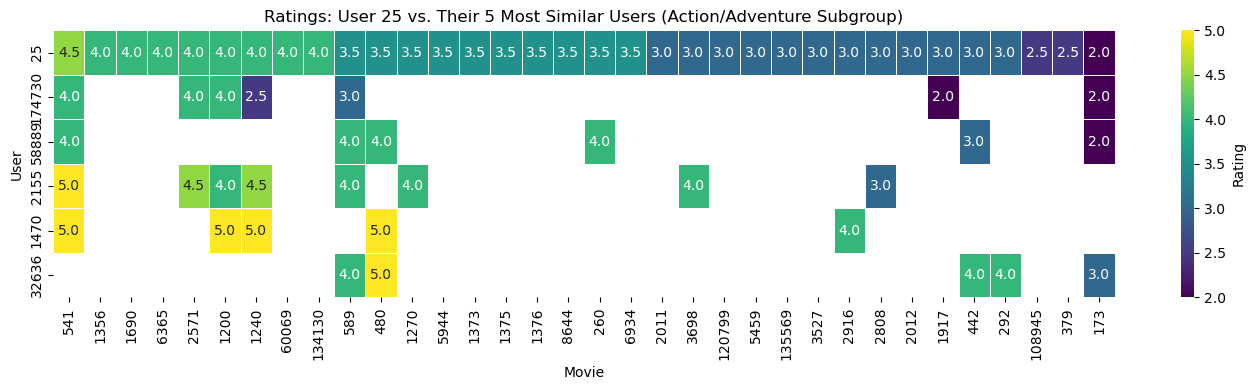

In [36]:
comparison_users_f1 = [query_user_id] + similar_ids_f1
print("Comparison users (Action/Adventure subgroup):", comparison_users_f1)

# Rebuild without filling, scoped to the Factor 1 subgroup
original_ratings_f1 = factor1_ratings.pivot(
    index='userId', columns='movieId', values='rating'
)

query_rated_f1 = original_ratings_f1.loc[query_user_id].dropna()

N = 100
top_movies_f1 = query_rated_f1.sort_values(ascending=False).head(N).index

comparison_matrix_f1 = original_ratings_f1.loc[comparison_users_f1, top_movies_f1]

plt.figure(figsize=(14, 4))
sns.heatmap(
    comparison_matrix_f1,
    annot=True,
    fmt='.1f',
    cmap='viridis',
    cbar_kws={'label': 'Rating'},
    linewidths=0.5,
)
plt.title(f"Ratings: User {query_user_id} vs. Their 5 Most Similar Users (Action/Adventure Subgroup)")
plt.xlabel("Movie")
plt.ylabel("User")
plt.tight_layout()
plt.show()

In [37]:
def mean_rating_gap_table(query_id, comparison_ids, ratings_matrix, label):
    rows = []
    query_ratings = ratings_matrix.loc[query_id]
    for other_id in comparison_ids:
        other_ratings = ratings_matrix.loc[other_id]
        shared = query_ratings.dropna().index.intersection(other_ratings.dropna().index)
        if len(shared) > 0:
            gap = (query_ratings[shared] - other_ratings[shared]).abs().mean()
            rows.append({'Neighbor': other_id, 'Shared Movies': len(shared), 'Avg. Rating Gap': round(gap, 2)})
    
    df_result = pd.DataFrame(rows)
    print(f"\n{label}")
    print(df_result.to_string(index=False))
    print(f"Average gap across neighbors: {df_result['Avg. Rating Gap'].mean():.2f}\n")
    return df_result

original_table = mean_rating_gap_table(
    query_user_id, similar_user_ids, original_ratings,
    "Original (Whole Sci-Fi) Neighbors"
)

factor1_table = mean_rating_gap_table(
    query_user_id, similar_ids_f1, original_ratings_f1,
    "Factor 1 (Action/Adventure) Neighbors"
)


Original (Whole Sci-Fi) Neighbors
 Neighbor  Shared Movies  Avg. Rating Gap
   115316              4             1.75
    17825              2             0.75
    55138              2             0.75
    49640              5             1.20
     2312              3             1.17
Average gap across neighbors: 1.12


Factor 1 (Action/Adventure) Neighbors
 Neighbor  Shared Movies  Avg. Rating Gap
   174730              7             0.50
    58889              6             0.33
     2155              8             0.44
     1470              5             1.00
    32636              5             1.00
Average gap across neighbors: 0.65



**Key Insights**  
- Restricting similarity computation to a single latent genre factor (Action/Adventure) rather than the full Sci-Fi umbrella meaningfully improved neighbor quality: the average rating gap on shared movies dropped from ~1.12 to ~0.65, a roughly 42% reduction in disagreement, with the heatmap confirming denser, more consistent overlap among real (non-imputed) ratings.
- This improvement is corroborated by a second, independent signal: shared-movie counts were also higher within the Factor 1 neighbor group (5-8 shared movies) than in the original whole-Sci-Fi group (2-5 shared movies), suggesting the Action/Adventure subgroup surfaces neighbors who are both more numerous in overlap and more consistent in taste, not just a coincidental improvement in one metric.
- This suggests that genre-level granularity matters for similarity-based recommendation, treating "Sci-Fi" as one taste profile likely obscures meaningfully different sub-audiences.
- Limitation: This result comes from a single query user and small neighbor-overlap counts, so it should be read as a promising, well-evidenced direction rather than a statistically validated finding.